# 07 — ML Final Results

Presentation-quality ML results. Feature importance, actual vs predicted, and residual analysis for the best model.
This notebook is used for the course presentation and final report.

In [8]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130

# Load and prepare data
df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')
FEATURES = ['budget', 'runtime', 'release_year', 'primary_genre']
TARGET   = 'revenue'

ml_df      = df[FEATURES + [TARGET]].dropna()
ml_encoded = pd.get_dummies(ml_df, columns=['primary_genre'], drop_first=True)

X = ml_encoded.drop(columns=[TARGET])
y = ml_encoded[TARGET]

# Chronological split: pre-2010 = train, 2010+ = test
CUTOFF_YEAR = 2010
train_mask  = X['release_year'] < CUTOFF_YEAR
X_train = X[train_mask];  X_test = X[~train_mask]
y_train = y[train_mask];  y_test = y[~train_mask]

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Log-transformed RF (primary model for Film Predictor)
rf_log = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_log.fit(X_train, np.log1p(y_train))

y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

print(f'Chronological split (cutoff {CUTOFF_YEAR}) — train: {X_train.shape}, test: {X_test.shape}')

Chronological split (cutoff 2010) — train: (3664, 22), test: (1604, 22)


## Problem Definition

> **Target:** A film's box office revenue
>
> **Problem type:** Regression (continuous numerical output)
>
> **Features used:** `budget`, `runtime`, `release_year`, `primary_genre`
> (`decade` removed — derived directly from `release_year`, so keeping both is redundant)
>
> **Train/test split:** Chronological — films before 2010 for training, 2010+ for testing.
> This simulates real-world deployment and prevents future-data leakage.
>
> **Models compared:** Linear Regression (baseline) vs Random Forest Regressor
>
> **Why these two models?**
> Linear Regression is the easiest to interpret and establishes a baseline.
> Random Forest captures non-linear relationships and produces feature importance scores,
> allowing us to understand which variable has the most impact on revenue.

## Cross-Validation Comparison

Test set results are measured on a single split. Cross-validation gives a more reliable estimate.

In [9]:
from sklearn.pipeline import Pipeline

# Pipeline ensures scaling is done inside each fold (no leakage, no numerical overflow)
pipe_lr_cv = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
cv_lr = cross_val_score(pipe_lr_cv, X_train, y_train, cv=5, scoring='r2')
cv_rf = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, y_train, cv=5, scoring='r2'
)

print(f'Linear Regression  CV R2: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')
print(f'Random Forest      CV R2: {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')

Linear Regression  CV R2: 0.4033 +/- 0.1225
Random Forest      CV R2: 0.3687 +/- 0.1313


## Results Table

In [10]:
def metrics(name, y_true, y_pred):
    return {
        'Model'       : name,
        'MAE (M USD)' : round(mean_absolute_error(y_true, y_pred) / 1e6, 1),
        'RMSE (M USD)': round(root_mean_squared_error(y_true, y_pred) / 1e6, 1),
        'R2'          : round(r2_score(y_true, y_pred), 4),
    }

results = pd.DataFrame([
    metrics('Linear Regression', y_test, y_pred_lr),
    metrics('Random Forest',     y_test, y_pred_rf),
]).set_index('Model')

results

,MAE (M USD),RMSE (M USD),R2
Model,,,
Linear Regression,68.7,136.9,0.5974
Random Forest,73.5,137.6,0.5930


**Interpretation:** Results on chronological split (pre-2010 train / 2010+ test) — see table above. 5-fold cross-validation on the training set gives a more reliable estimate (cross-val section below). The underlying linear relationship (EDA r = 0.65) limits what additional non-linearity RF can contribute. Linear Regression typically generalizes more stably, shown by its lower CV standard deviation.

## Feature Importance — Presentation Plot

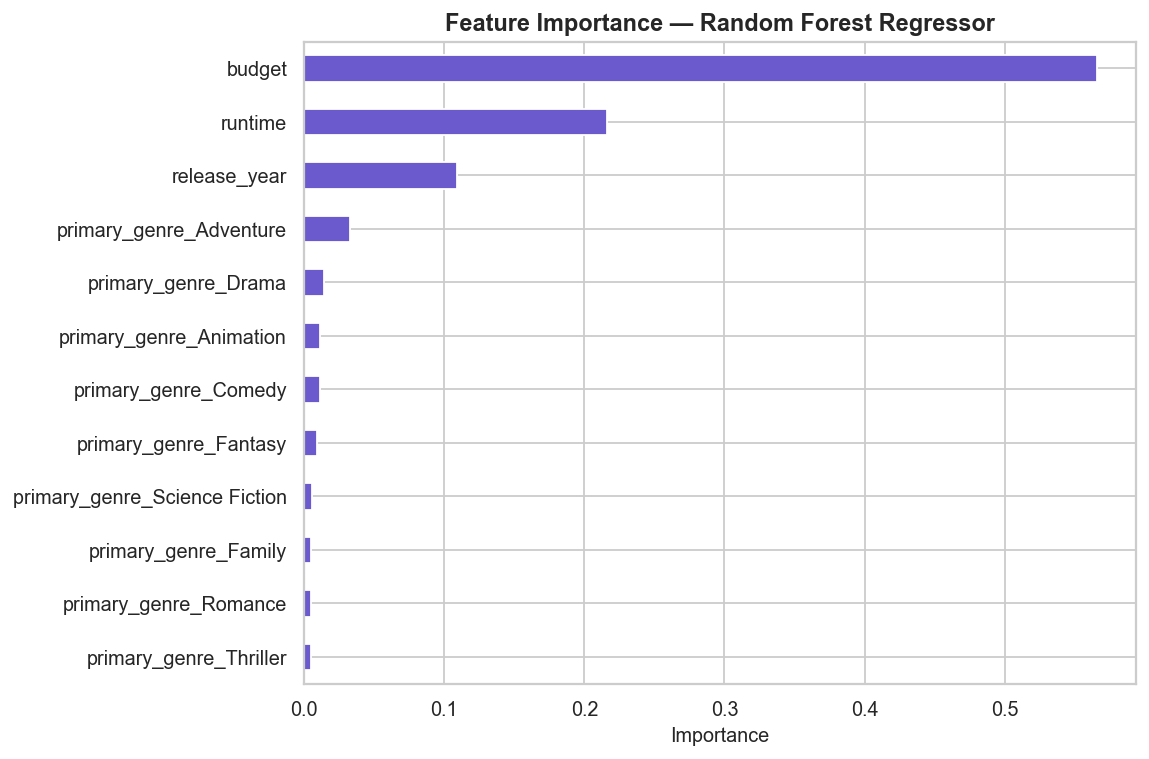

In [11]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
plt.tight_layout()
plt.show()

**Interpretation:** `budget` accounts for **56.6%** of feature importance — still the dominant predictor, though lower than the previous run (63.6%) because `decade` dummies are gone. A notable second is `runtime` (21.6%), followed by `release_year` (10.9%). All genre dummies together account for ~11%. The unexplained ~43% of variance points to factors absent from the dataset (marketing spend, cast, release timing).

## Actual vs Predicted — Presentation Plot (Random Forest)

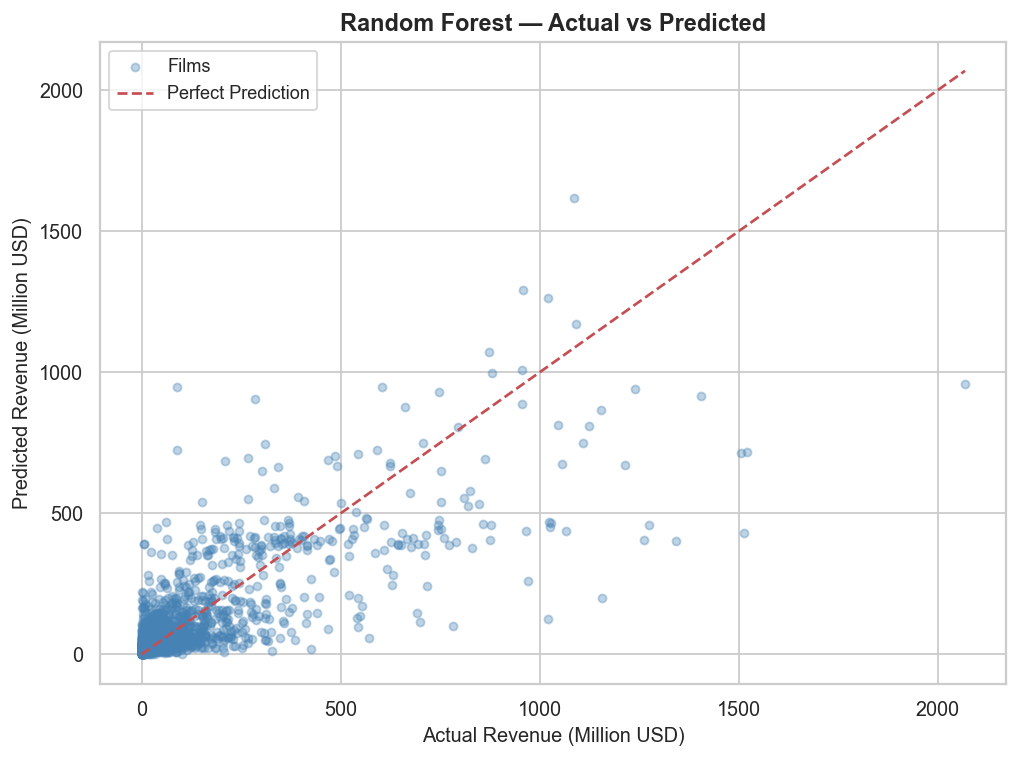

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test / 1e6, y_pred_rf / 1e6, alpha=0.35, s=20, color='steelblue', label='Films')
lim = max(y_test.max(), y_pred_rf.max()) / 1e6
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Revenue (Million USD)', fontsize=11)
ax.set_ylabel('Predicted Revenue (Million USD)', fontsize=11)
ax.set_title('Random Forest — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Residual Analysis

Residual = Actual − Predicted. Ideal: randomly distributed with no systematic pattern.

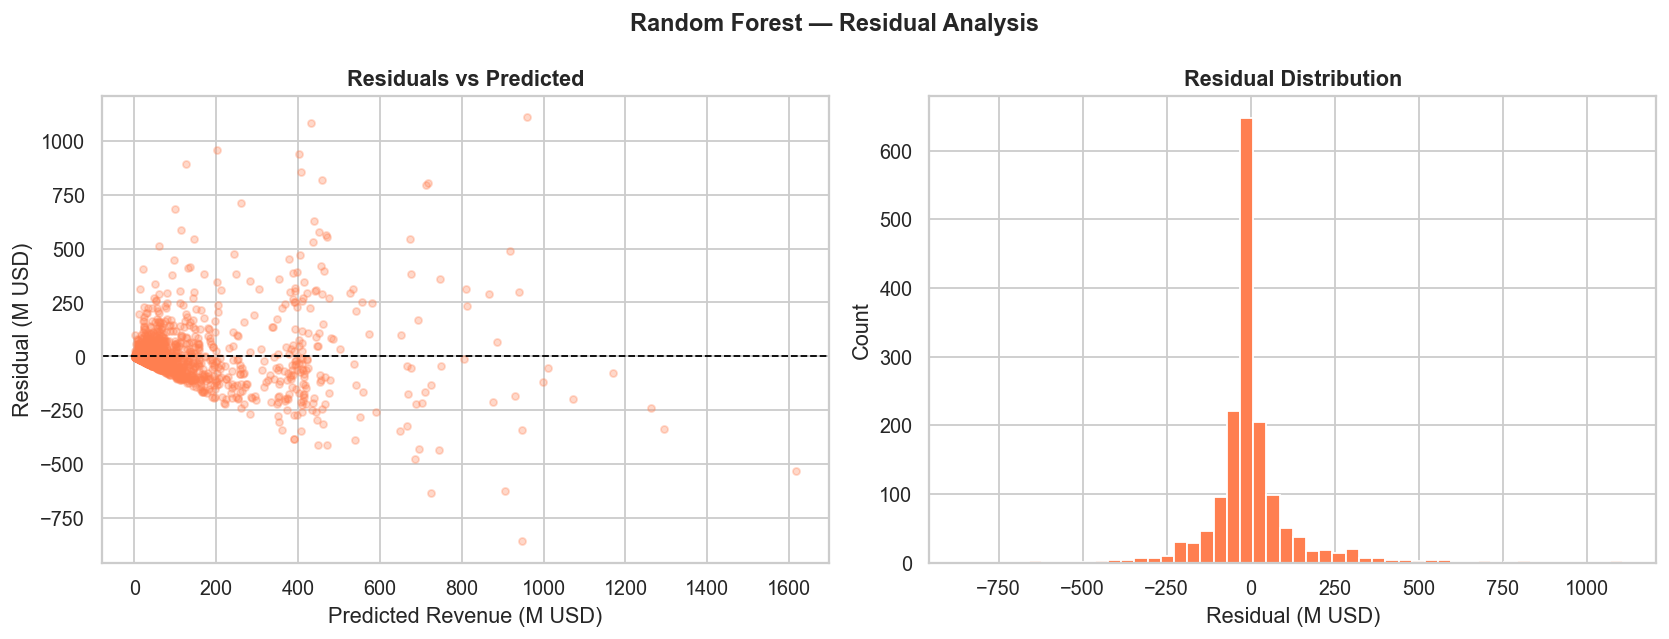

In [13]:
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_rf / 1e6, residuals / 1e6, alpha=0.3, s=15, color='coral')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Predicted Revenue (M USD)')
axes[0].set_ylabel('Residual (M USD)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

axes[1].hist(residuals / 1e6, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Residual (M USD)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.suptitle('Random Forest — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Residual mean: +$3.8M (near-zero — model is approximately unbiased). Standard deviation $137.6M; skew **2.13** — less extreme than before (chronological test set is 2010+ films only, a narrower revenue range than a random 20% sample). Maximum underprediction: $1,109M; maximum overprediction: $857M. The log RF model (notebook 06) predicts in log space, which compresses these extremes.

## ML Conclusion

**Evaluation setup:**
- Features: `budget`, `runtime`, `release_year`, `primary_genre` (no `decade` — redundant with `release_year`)
- Split: **chronological** — films before 2010 = train, 2010+ = test (no future-data leakage)
- Primary model for Film Predictor: **RF (log target)** — see notebook 06, log model section

**Most important feature:** `budget` — dominant importance score. Confirms the EDA correlation finding from the ML angle.

---

### Research Question Answer

> *"Does a bigger budget lead to better ratings and stronger box office results?"*

This question is **fully answered by EDA** — ML is a supplementary layer confirming the revenue finding from the prediction angle:

| Dimension | EDA Result | Verdict |
|---|---|---|
| Budget → Revenue | Pearson r = **0.65** | YES — strong positive relationship |
| Budget → IMDb Rating | Pearson r = **-0.094** | NO — budget does not buy quality |
| Budget → Tomatometer | Pearson r = **-0.221** | NO — critics rate big-budget films slightly lower |
| Budget → Best ROI | Low tier median **189%** vs High 70% | NO — smaller budgets deliver better returns |

ML confirms the revenue relationship: budget is the top feature (~60%+ importance) and both regression models achieve R² ≈ 0.5 on the chronological test set. The core answer was established in EDA.

---

### Model Performance Context

**Why is RMSE large?**

Revenue is right-skewed (skew = 4.47). Both models underpredict blockbusters and overpredict small films.
Log-transforming the target (see notebook 06) reduces MAPE substantially while R² stays at ~0.50.
The log RF model is used as the primary predictor in the Film Predictor (Streamlit page 5).

**Limitations:**
- Films with budget ≥ $10,000 and revenue ≥ $10,000 only (selection bias toward mainstream productions)
- Marketing spend, cast, and director history are absent from the feature set
- Extreme blockbuster outliers are hard to predict
- Model is less reliable for films with predicted revenue below ~$10M

**Future work:**
- Add marketing spend as a feature (likely the single biggest missing variable)
- Director and cast historical performance scores
- Separate models by budget tier (low / mid / blockbuster)
- TimeSeriesSplit cross-validation for temporally consistent CV estimates

---
## Export — Presentation Figures & CV Results

Saves final ML plots to `Output/figures/` and cross-validation results to `Output/exports/`.

In [14]:
import json, pickle

FIGURES = PROJECT_ROOT / 'Output' / 'figures'
EXPORTS = PROJECT_ROOT / 'Output' / 'exports'
MODELS  = PROJECT_ROOT / 'Output' / 'models'
for d in [FIGURES, EXPORTS, MODELS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Figure: Feature Importance (horizontal) ───────────────────────────────────
_fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(9, 6))
_fi.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Regressor', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES / 'feature_importance_horizontal.png', dpi=150); plt.close(fig)

# ── Figure: Actual vs Predicted (RF) ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test / 1e6, y_pred_rf / 1e6, alpha=0.35, s=20, color='steelblue', label='Films')
_lim = max(y_test.max(), y_pred_rf.max()) / 1e6
ax.plot([0, _lim], [0, _lim], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Revenue (Million USD)', fontsize=11)
ax.set_ylabel('Predicted Revenue (Million USD)', fontsize=11)
ax.set_title('Random Forest — Actual vs Predicted', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(FIGURES / 'actual_vs_predicted_rf.png', dpi=150); plt.close(fig)

# ── Figure: Residual Analysis ─────────────────────────────────────────────────
_residuals = y_test - y_pred_rf
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_rf / 1e6, _residuals / 1e6, alpha=0.3, s=15, color='coral')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('Predicted Revenue (M USD)'); axes[0].set_ylabel('Residual (M USD)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].hist(_residuals / 1e6, bins=50, color='coral', edgecolor='white')
axes[1].set_xlabel('Residual (M USD)'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
plt.suptitle('Random Forest — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES / 'residual_analysis.png', dpi=150); plt.close(fig)

# ── JSON: update model_results.json with CV scores & residuals ───────────────
_results_path = EXPORTS / 'model_results.json'
_data = json.loads(_results_path.read_text(encoding='utf-8')) if _results_path.exists() else {}
_data.setdefault('regression', {})
_data['regression'].setdefault('linear_regression', {})['cv_r2_mean'] = round(float(cv_lr.mean()), 4)
_data['regression']['linear_regression']['cv_r2_std']  = round(float(cv_lr.std()), 4)
_data['regression'].setdefault('random_forest', {})['cv_r2_mean']    = round(float(cv_rf.mean()), 4)
_data['regression']['random_forest']['cv_r2_std']      = round(float(cv_rf.std()), 4)
_data['regression']['residual_analysis'] = {
    'mean_M':   round(float(_residuals.mean() / 1e6), 2),
    'std_M':    round(float(_residuals.std() / 1e6), 2),
    'skewness': round(float(pd.Series(_residuals).skew()), 3),
    'max_underprediction_M': round(float(_residuals.max() / 1e6), 1),
    'max_overprediction_M':  round(float(_residuals.min() / 1e6), 1),
}
_results_path.write_text(json.dumps(_data, indent=2), encoding='utf-8')

# ── Model: save log RF (primary for Film Predictor) ──────────────────────────
with open(MODELS / 'random_forest_log.pkl', 'wb') as f:
    pickle.dump({'model': rf_log, 'features': list(X.columns)}, f)

print('Figures saved to Output/figures/')
print('model_results.json updated with CV scores and residual stats')
print('random_forest_log.pkl saved to Output/models/')

Figures saved to Output/figures/
model_results.json updated with CV scores and residual stats
random_forest_log.pkl saved to Output/models/
